# 08 — Producer FX Signal: BRL/USD → ICE KC (L1)

**Goal:** Proof of concept. Test whether trends in producer-country exchange rates — primarily USD/BRL — carry *exploitable predictive information* for ICE Arabica (KC) prices at horizons a US coffee buyer can act on (1 week – 12 months).

**The hypothesis (two channels, same sign):**

1. **Producer-selling channel** — Brazil produces ~40% of world Arabica. KC is quoted in USD; Brazilian growers' costs are in BRL. When the real weakens (USD/BRL ↑), the BRL-denominated value of the crop rises even at unchanged USD prices, improving grower margins and encouraging forward selling and hedging — incremental *supply* pressure on the USD price.
2. **FX-as-forward-price channel** — Chen, Rogoff & Rossi (2010, *QJE*, "Can Exchange Rates Forecast Commodity Prices?") found commodity-exporter exchange rates predict commodity prices better than the reverse: the currency is a forward-looking asset price that absorbs expectations about the exporter's terms of trade *first*.

Both channels imply the same testable statement: **past BRL weakening → lower KC ahead (β < 0)**. This notebook does not need to separate the channels — a timing rule only needs the lead to exist and survive controls.

**What could fake the result (designed against, not around):**

- **The dollar costume.** USD/BRL and KC both load on broad USD strength. Any "BRL signal" must survive a DXY control or it is just the dollar. (§4c)
- **Own-momentum proxy.** BRL and KC returns are contemporaneously correlated, so BRL momentum partially *is* lagged KC momentum. KC's own momentum enters as a control. (§4c)
- **Reverse causality.** Coffee is only ~3% of Brazilian exports, so KC→BRL should be weak — but we test the reverse direction explicitly rather than assume. (§4c, §4d)
- **Multiple testing.** The k×h scan runs 40 regressions; at 5% we *expect* ~2 false positives. Significance alone is not evidence — we require sign-consistent clusters + out-of-sample confirmation. (§4b note, §5)
- **Regime instability.** Late 2024 is an adversarial case sitting in-sample: USD/BRL blew out past 6.0 while KC *spiked* to record highs on a supply shock. The contemporaneous relation visibly breaks under supply shocks; we measure rolling stability instead of trusting one full-sample r. (§4a)

**Gates:**

1. **G1 — Mechanism sign:** contemporaneous monthly `r(Δlog USDBRL, Δlog KC) ≤ −0.20` over the 2010–2024 core window. If the basic negative co-movement isn't there, the premise fails.
2. **G2 — Predictive edge:** at least one *adjacent pair* of cells in the k×h grid with β < 0 and HAC p < 0.05 **after** DXY and KC-momentum controls. Isolated significant cells don't count (multiple-testing discipline).
3. **G3 — Economic value:** the walk-forward FX timing rule (§6) improves procurement cost by at least **1.0% of budget** vs never shifting purchases, under *deferral accounting* (shift volume between period *t* and period *t+h*, at a decision cadence matched to the signal's horizon; saving = Σ δₜ·(P₊ₕ − Pₜ) / Σ Pₜ). The 01-comparable signal-weighted-average metric is reported alongside — §6 explains why it is the wrong yardstick for a *return* forecast and is kept only for cross-notebook comparability.

A failed gate is a *valid* proof-of-concept outcome — the kill criterion is documented up front so the conclusion can't drift to fit the data.

**Data source:** Yahoo Finance — `KC=F` (ICE Coffee C front-month, same instrument as notebook 01), `BRL=X` (USD/BRL), `DX-Y.NYB` (US Dollar Index), plus origin-country FX pairs for the §7 generalization. No API keys required.

## 0. Setup

All tunable parameters live here. `K_WEEKS` are the trailing FX-momentum lookbacks (the *signal* side); `H_WEEKS` are the forward KC return horizons (the *target* side) — together they define the §4 scan grid. `CORE_START/END` bound the statistical window (matching notebook 01's 2010–2024 core, so results are comparable), while `BACKTEST_START` reaches back to 2008 so 26-week lookbacks are fully formed by 2010. Gate thresholds are constants so §8 can evaluate them programmatically.

In [1]:
import sys
import warnings
from datetime import date
from pathlib import Path

REPO_ROOT = Path("../..")                       # parity with notebook 01; no repo
sys.path.insert(0, str(REPO_ROOT.resolve()))    # modules are needed in this notebook

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import statsmodels.api as sm  # noqa: E402
import yfinance as yf  # noqa: E402
from scipy import stats  # noqa: E402

BACKTEST_START = date(2008, 1, 1)     # fetch start (warm-up for 26w lookbacks)
BACKTEST_END   = date.today()
CORE_START, CORE_END = "2010-01-01", "2024-12-31"   # statistical core window
OOS_START      = "2015-01-01"         # first out-of-sample prediction (§5, §6)

K_WEEKS = [1, 2, 4, 13, 26]                    # FX momentum lookbacks (~1w…6m)
H_WEEKS = [1, 2, 4, 8, 13, 26, 39, 52]         # forward KC horizons  (~1w…12m)

# Gate thresholds (see header)
G1_R_MAX       = -0.20   # monthly contemporaneous r must be ≤ this
G2_P_MAX       = 0.05    # controlled HAC p-value threshold
G3_SAVING_MIN  = 1.0     # % saving vs naive monthly averaging

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Backtest window : {BACKTEST_START} → {BACKTEST_END}")
print(f"Core window     : {CORE_START} → {CORE_END}")
print(f"Scan grid       : {len(K_WEEKS)} lookbacks × {len(H_WEEKS)} horizons "
      f"= {len(K_WEEKS)*len(H_WEEKS)} regressions")

Backtest window : 2008-01-01 → 2026-07-09
Core window     : 2010-01-01 → 2024-12-31
Scan grid       : 5 lookbacks × 8 horizons = 40 regressions


## 1. Fetch Data

Everything comes from Yahoo Finance so the notebook runs with no API keys. Quote convention matters and is easy to get backwards: Yahoo's `XXX=X` tickers quote **units of local currency per 1 USD** (`BRL=X` ≈ 5.4 means 5.4 reais per dollar). So for *every* pair here, **a rising value = local currency weakening** — one consistent sign convention across BRL and the §7 index currencies. §2 sanity-checks this numerically rather than trusting the assumption.

Each ticker is downloaded independently inside `try/except` — a single dead origin-currency ticker must not kill the notebook. `KC`, `BRL`, and `DXY` are hard requirements; the origin currencies are optional inputs to §7 and simply drop out of the index if unavailable.

In [2]:
# ── Ticker map ─────────────────────────────────────────────────────────────
# Core (required): KC futures, USD/BRL, Dollar Index.
# Origin FX (optional, §7): top US green-coffee origins with a quoted currency.
ORIGIN_FX = ["BRL", "COP", "PEN", "MXN", "GTQ", "HNL", "NIO", "VND", "IDR", "ETB"]

ALL_TICKERS = {"KC": "KC=F", "DXY": "DX-Y.NYB"}
ALL_TICKERS.update({c: f"{c}=X" for c in ORIGIN_FX})

series, failures = {}, {}
for name, ticker in ALL_TICKERS.items():
    try:
        raw = yf.download(
            ticker,
            start=BACKTEST_START.isoformat(),
            end=BACKTEST_END.isoformat(),
            auto_adjust=True,
            progress=False,
        )
        s = raw["Close"].squeeze().dropna()
        if len(s) < 250:                      # less than ~1 trading year → unusable
            raise ValueError(f"only {len(s)} rows")
        idx = pd.to_datetime(s.index)
        if getattr(idx, "tz", None) is not None:
            idx = idx.tz_localize(None)       # strip tz so all series align on dates
        s.index = idx
        s.index.name = "date"
        series[name] = s.rename(name)
    except Exception as e:                    # noqa: BLE001 — report, don't crash
        failures[name] = f"{type(e).__name__}: {e}"

missing_core = [c for c in ("KC", "BRL", "DXY") if c not in series]
if missing_core:
    raise RuntimeError(f"Required series failed to download: {missing_core} — {failures}")

prices = pd.concat(series.values(), axis=1).sort_index()

print(f"{'series':6s} {'first':>12s} {'last':>12s} {'rows':>7s}")
print("─" * 42)
for name in ALL_TICKERS:
    if name in series:
        s = series[name]
        first, last = s.index[0].date(), s.index[-1].date()
        print(f"{name:6s} {str(first):>12s} {str(last):>12s} {len(s):>7d}")
    else:
        print(f"{name:6s} {'FAILED — ' + failures[name]}")

series        first         last    rows
──────────────────────────────────────────
KC       2008-01-02   2026-07-08    4656
DXY      2008-01-02   2026-07-09    4659
BRL      2008-01-01   2026-07-08    4797
COP      2008-01-01   2026-07-08    4809
PEN      2008-01-01   2026-07-08    4821
MXN      2008-01-01   2026-07-08    4823
GTQ      2008-01-01   2026-07-08    4824
HNL      2008-01-01   2026-07-08    4819
NIO      2008-01-01   2026-07-08    4798
VND      2008-01-01   2026-07-08    4824
IDR      2008-01-01   2026-07-08    4801
ETB      2008-01-01   2026-07-08    4819


C:\Users\LeAadi\AppData\Local\Temp\ipykernel_9676\2915279828.py:35: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  prices = pd.concat(series.values(), axis=1).sort_index()


## 2. Data Quality

Three checks before any statistics:

1. **Quote-convention sanity.** Median 2020+ values are compared against known ranges (USD/BRL ≈ 4–6.5, USD/COP ≈ 3,400–4,400, …). If Yahoo ever inverted a pair, the sign of every result in this notebook would flip — this check makes that failure loud instead of silent.
2. **Float-status diagnostic.** Several origin currencies are pegged, crawling, or heavily managed (GTQ, HNL, NIO, VND; ETB was a managed crawl until its July-2024 float). A managed rate barely moves, so it carries almost no market information — including it in the §7 index just dilutes the signal with zeros. Classification is *quantitative*, not by label: a currency qualifies as informative if, over the last 3 years, annualized daily volatility ≥ 4% **and** the fraction of exactly-zero daily changes < 15%. A crawling peg fails the vol test even though it moves every day; a hard peg fails the zero-fraction test.
3. **Visual inspection** of KC vs USD/BRL over the full window — the eye catches splice errors and gaps that summary stats miss. The 2014–16 episode (BRL crisis, KC slide — mechanism-consistent) and late-2024 (weak BRL, KC spike — mechanism-inverted) should both be visible.

Quote convention check: all FX medians in expected local-per-USD ranges ✓

ccy    ann.vol  zero-frac   verdict
──────────────────────────────────────────
BRL      0.124      0.001   float — informative
COP      0.147      0.001   float — informative
PEN      0.233      0.084   float — informative
MXN      0.113      0.000   float — informative
GTQ      0.042      0.009   float — informative
HNL      0.149      0.118   float — informative
NIO      0.074      0.117   float — informative
VND      0.027      0.098   managed/pegged — excluded from index
IDR      0.107      0.006   float — informative
ETB      0.255      0.111   float — informative


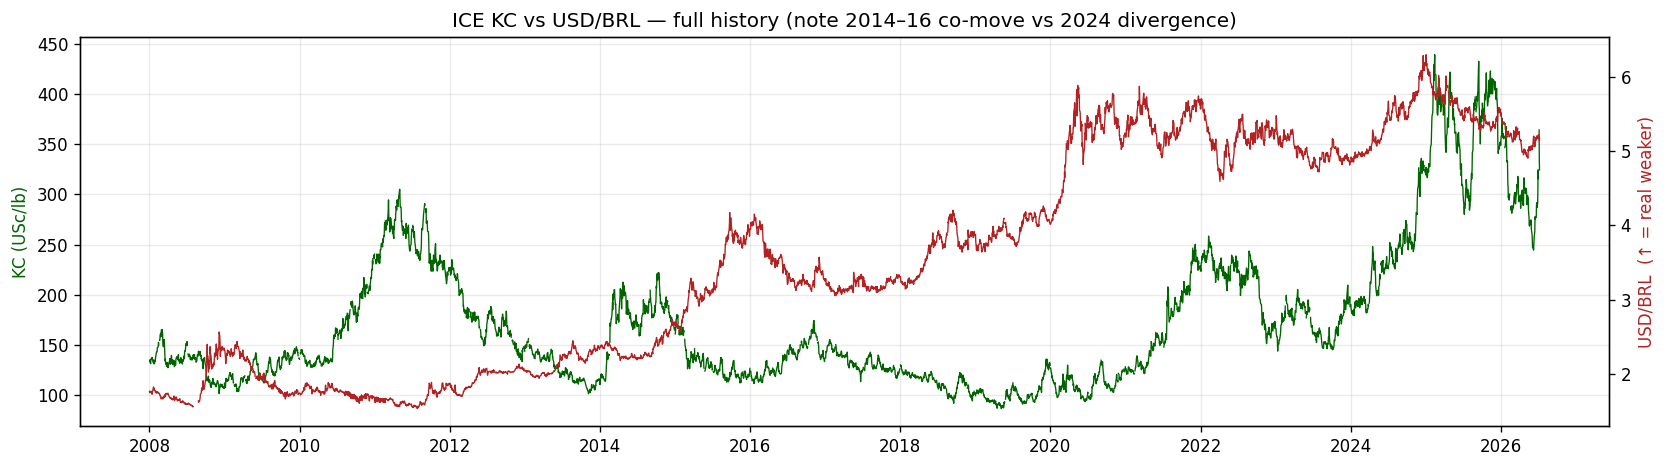


NaN share in core window (before alignment — FX and KC trade different calendars):
KC     0.0363
BRL    0.0018
DXY    0.0358


In [3]:
# ── 1. Quote-convention sanity (warn, don't crash — ranges drift over time) ─
EXPECTED_MEDIAN_2020PLUS = {           # units of local per USD, loose bounds
    "BRL": (3.5, 7.0),   "COP": (3000, 4800), "PEN": (3.0, 4.3),
    "MXN": (15, 23),     "GTQ": (7.0, 8.5),   "HNL": (23, 27),
    "NIO": (33, 38),     "VND": (22000, 27000),
    "IDR": (13500, 17500), "ETB": (30, 140),
}
conv_warnings = []
for cur, (lo, hi) in EXPECTED_MEDIAN_2020PLUS.items():
    if cur not in prices.columns:
        continue
    med = prices.loc["2020-01-01":, cur].median()
    if not (lo <= med <= hi):
        conv_warnings.append(f"  {cur}: median {med:,.2f} outside expected [{lo}, {hi}]")
if conv_warnings:
    print("⚠ QUOTE-CONVENTION WARNINGS — inspect before trusting signs:")
    print("\n".join(conv_warnings))
else:
    print("Quote convention check: all FX medians in expected local-per-USD ranges ✓")

# ── 2. Float-status diagnostic (last 3 years of daily data) ────────────────
VOL_MIN, ZERO_FRAC_MAX = 0.04, 0.15
cutoff3y = prices.index.max() - pd.DateOffset(years=3)
float_status = {}
print(f"\n{'ccy':5s} {'ann.vol':>8s} {'zero-frac':>10s}   verdict")
print("─" * 42)
for cur in ORIGIN_FX:
    if cur not in prices.columns:
        float_status[cur] = False
        print(f"{cur:5s} {'—':>8s} {'—':>10s}   unavailable")
        continue
    ret3 = np.log(prices[cur]).diff().loc[cutoff3y:].dropna()
    ann_vol   = ret3.std() * np.sqrt(252)
    zero_frac = (ret3.abs() < 1e-6).mean()
    ok = (ann_vol >= VOL_MIN) and (zero_frac < ZERO_FRAC_MAX)
    float_status[cur] = bool(ok)
    verdict = "float — informative" if ok else "managed/pegged — excluded from index"
    print(f"{cur:5s} {ann_vol:8.3f} {zero_frac:10.3f}   {verdict}")

# ── 3. Visual: KC vs USD/BRL, full history ─────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(prices.index, prices["KC"], lw=0.8, color="darkgreen", label="KC=F (USc/lb)")
ax1.set_ylabel("KC (USc/lb)", color="darkgreen")
ax1.grid(alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(prices.index, prices["BRL"], lw=0.8, color="firebrick", label="USD/BRL")
ax2.set_ylabel("USD/BRL  (↑ = real weaker)", color="firebrick")
ax1.set_title("ICE KC vs USD/BRL — full history (note 2014–16 co-move vs 2024 divergence)")
fig.tight_layout()
plt.show()

core_nan = prices.loc[CORE_START:CORE_END, ["KC", "BRL", "DXY"]].isna().mean()
print("\nNaN share in core window (before alignment — FX and KC trade different calendars):")
print(core_nan.round(4).to_string())

## 3. Feature Engineering

**Why a weekly grid.** Daily data is dominated by asynchronous-close noise (BRL trades nearly 24h, KC settles in the NY afternoon — daily "lead-lag" at lag 1 can be pure timing artifact). Monthly data has too few observations to resolve 1–4 week horizons. Weekly (`W-FRI` last observation) is the compromise: ~780 core observations, and a week absorbs the intraday timing mismatch. Monthly aggregates reappear in §4a (stability) and §6 (the purchase-cadence timing rule).

**Definitions** (all natural logs):

```
fx_mom_k[t]  = log( USDBRL[t] / USDBRL[t−k] )    # trailing — uses only data ≤ t
dxy_mom_k[t] = log( DXY[t]    / DXY[t−k] )       # control, same construction
kc_mom_k[t]  = log( KC[t]     / KC[t−k] )        # control, same construction
fwd_h[t]     = log( KC[t+h]   / KC[t]   )        # target — strictly after t
```

Positive `fx_mom` = the real *weakened* over the lookback. The hypothesis is `corr(fx_mom_k[t], fwd_h[t]) < 0`. Signal and target windows share only the single timestamp `t` — no overlap, no look-ahead. The cost of this construction is *serial* overlap across neighboring `t` (an h-week forward return overlaps h−1 neighbors), which inflates naive t-stats; §4 handles it with Newey–West (HAC) errors sized to the overlap.

In [4]:
# ── Weekly master frame ─────────────────────────────────────────────────────
# W-FRI .last(): the last available observation on/before each Friday.
# dropna(how="any") on the three core columns: a week only enters if KC, BRL
# and DXY all have data — keeps every regression on an identical calendar.
wk = (
    prices[["KC", "BRL", "DXY"]]
    .resample("W-FRI").last()
    .dropna(how="any")
)
lp = np.log(wk)   # log prices — momenta and forward returns are log differences

for k in K_WEEKS:                                   # trailing momenta (≤ t)
    wk[f"fx_mom_{k}w"]  = lp["BRL"] - lp["BRL"].shift(k)
    wk[f"dxy_mom_{k}w"] = lp["DXY"] - lp["DXY"].shift(k)
    wk[f"kc_mom_{k}w"]  = lp["KC"]  - lp["KC"].shift(k)

for h in H_WEEKS:                                   # forward targets (> t)
    wk[f"fwd_{h}w"] = lp["KC"].shift(-h) - lp["KC"]

wk_core = wk.loc[CORE_START:CORE_END]
print(f"Weekly rows total : {len(wk)}   ({wk.index[0].date()} → {wk.index[-1].date()})")
print(f"Weekly rows core  : {len(wk_core)}")
print(f"Columns           : {len(wk.columns)} "
      f"(3 levels + {3*len(K_WEEKS)} momenta + {len(H_WEEKS)} forwards)")
wk_core.filter(regex="^(KC|BRL|fx_mom_4w|fwd_4w)").dropna().tail(3)

Weekly rows total : 964   (2008-01-04 → 2026-07-10)
Weekly rows core  : 783
Columns           : 26 (3 levels + 15 momenta + 8 forwards)


,KC,BRL,fx_mom_4w,fwd_4w
date,,,,
2024-12-13,320.850006,5.9961,0.035271,0.009307
2024-12-20,325.000000,6.1516,0.056426,0.010255
2024-12-27,322.649994,6.1485,0.022135,0.074340


## 4. Predictive Structure

### 4a. Contemporaneous Relation & Regime Stability

Before asking whether FX *leads* KC, establish that the two co-move at all and — more importantly — *when they don't*. The contemporaneous correlation is measured at daily, weekly, and monthly frequency (correlation typically strengthens with aggregation as microstructure noise averages out; the monthly figure is **Gate G1**).

The rolling 104-week correlation is the honesty check. A single full-sample r hides the fact that this relationship has regimes: demand/macro shocks (2015, 2020) push FX and KC through the same dollar channel → strongly negative r; Brazil-specific *supply* shocks (2021 frost, 2024 drought) rally KC while leaving — or even weakening — the real → r collapses toward zero or flips. If the rolling correlation spends long stretches near zero, a static timing rule is fragile and §6's walk-forward test becomes the real arbiter.

Contemporaneous r(Δlog KC, Δlog USDBRL), core 2010–2024:
  daily    r = -0.051   p = 1.93e-03   n = 3765
  weekly   r = -0.200   p = 1.68e-08   n = 783
  monthly  r = -0.316   p = 1.59e-05   n = 180

Gate G1 input: monthly r = -0.316 (threshold ≤ -0.20)


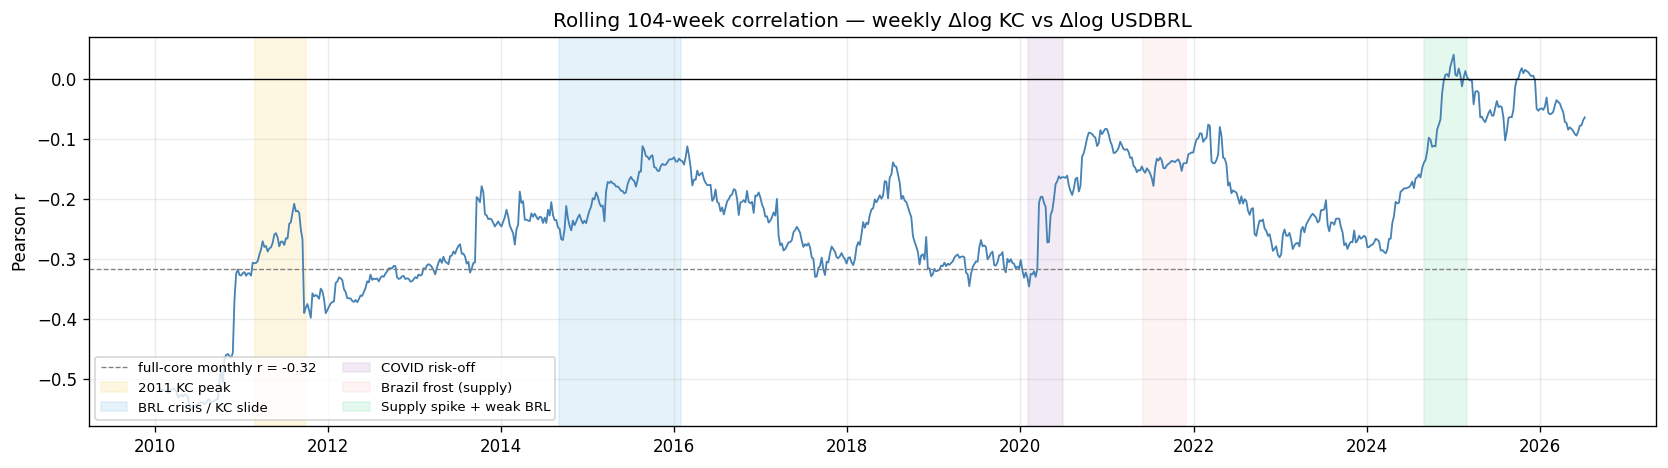

Share of core weeks with |rolling r| < 0.15 : 16.3% (regime-dependence measure)


In [5]:
# ── Contemporaneous r at three frequencies (core window) ───────────────────
def contemporaneous_r(freq_rule):
    """Pearson r of aligned log-returns of KC vs USDBRL at a given frequency.
    freq_rule: None = daily (native), else a pandas resample rule."""
    px = prices[["KC", "BRL"]].dropna()
    if freq_rule is not None:
        px = px.resample(freq_rule).last()
    ret = np.log(px).diff().dropna().loc[CORE_START:CORE_END]
    r, p = stats.pearsonr(ret["KC"], ret["BRL"])
    return r, p, len(ret)

print("Contemporaneous r(Δlog KC, Δlog USDBRL), core 2010–2024:")
results_4a = {}
for label, rule in [("daily", None), ("weekly", "W-FRI"), ("monthly", "ME")]:
    r, p, n = contemporaneous_r(rule)
    results_4a[label] = r
    print(f"  {label:8s} r = {r:+.3f}   p = {p:.2e}   n = {n}")

R_MONTHLY_CONTEMP = results_4a["monthly"]          # ← Gate G1 input
print(f"\nGate G1 input: monthly r = {R_MONTHLY_CONTEMP:+.3f} "
      f"(threshold ≤ {G1_R_MAX:+.2f})")

# ── Rolling 104-week correlation of weekly returns ─────────────────────────
ret_w = np.log(wk[["KC", "BRL"]]).diff().dropna()
roll_r = ret_w["KC"].rolling(104).corr(ret_w["BRL"])

event_bands = [
    ("2011-03", "2011-10", "2011 KC peak",             "#f9e79f"),
    ("2014-09", "2016-02", "BRL crisis / KC slide",    "#aed6f1"),
    ("2020-02", "2020-07", "COVID risk-off",           "#d7bde2"),
    ("2021-06", "2021-12", "Brazil frost (supply)",    "#fadbd8"),
    ("2024-09", "2025-03", "Supply spike + weak BRL",  "#abebc6"),
]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_r.index, roll_r, lw=1.1, color="steelblue")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(R_MONTHLY_CONTEMP, color="gray", lw=0.8, ls="--",
           label=f"full-core monthly r = {R_MONTHLY_CONTEMP:+.2f}")
for start, end, label, shade in event_bands:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.30,
               color=shade, label=label)
ax.set_title("Rolling 104-week correlation — weekly Δlog KC vs Δlog USDBRL")
ax.set_ylabel("Pearson r")
ax.legend(fontsize=8, loc="lower left", ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

frac_near_zero = (roll_r.loc[CORE_START:CORE_END].abs() < 0.15).mean()
print(f"Share of core weeks with |rolling r| < 0.15 : {frac_near_zero:.1%} "
      "(regime-dependence measure)")

### 4b. Lead–Lag Scan — Univariate Grid

For every (k, h) pair we fit, on the core window:

```
fwd_h[t] = α + β · fx_mom_k[t] + ε[t]
```

with **Newey–West (HAC) standard errors, maxlags = ⌈1.5·max(h,k)⌉** — the h-week forward return mechanically overlaps its h−1 neighbors (MA(h−1) errors), and the k-week regressor overlaps similarly, so plain OLS t-stats would be inflated severalfold at long horizons. The hypothesis predicts **β < 0**.

**Read this grid with discipline.** It contains 40 regressions; at the 5% level, ~2 significant cells are *expected under the null*. A lone starred cell is noise until proven otherwise. What would constitute real structure: a **contiguous, sign-consistent region** (adjacent k's and h's agreeing — the underlying process is smooth in both dimensions, so a genuine effect cannot live in one isolated cell), which then **survives the §4c controls** and **confirms out-of-sample in §5**. This cell renders the raw map; judgment waits.

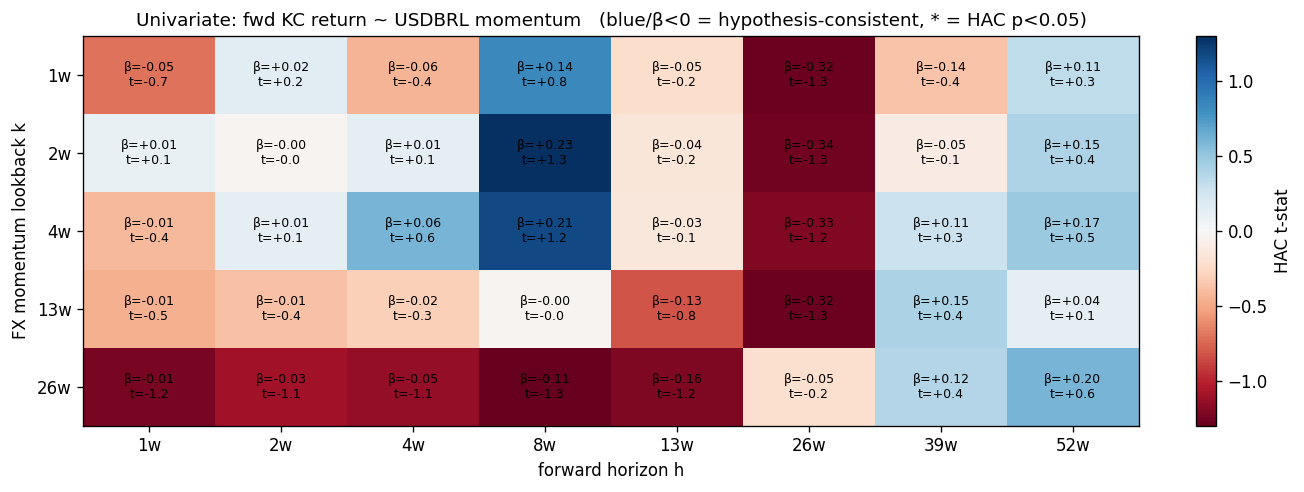

Significant cells (p<0.05): 0 of 40 — expected under null ≈ 2.0


In [6]:
# ── Generic grid engine (reused in §4c for controls and §7 for the index) ──
def grid_regressions(df, sig_prefix, controls=False, target_prefix="fwd",
                     k_list=K_WEEKS, h_list=H_WEEKS,
                     ctrl_prefixes=("dxy_mom", "kc_mom")):
    """OLS of target_prefix_{h}w on sig_prefix_{k}w (+ same-k controls), HAC errors.

    Inputs : df with the named columns; core window is applied by caller.
    Output : tidy DataFrame — one row per (k, h) with beta, t, p, n.
    """
    rows = []
    for k in k_list:
        for h in h_list:
            xcols = [f"{sig_prefix}_{k}w"]
            if controls:
                xcols += [f"{c}_{k}w" for c in ctrl_prefixes]
            ycol = f"{target_prefix}_{h}w"
            sub = df[xcols + [ycol]].dropna()
            if len(sub) < 60:                       # too short to trust HAC
                rows.append(dict(k=k, h=h, beta=np.nan, t=np.nan,
                                 p=np.nan, n=len(sub)))
                continue
            X = sm.add_constant(sub[xcols])
            L = int(np.ceil(1.5 * max(h, k)))       # overlap-aware HAC lags
            res = sm.OLS(sub[ycol], X).fit(cov_type="HAC",
                                           cov_kwds={"maxlags": L})
            rows.append(dict(k=k, h=h,
                             beta=res.params.iloc[1],
                             t=res.tvalues.iloc[1],
                             p=res.pvalues.iloc[1],
                             n=int(res.nobs)))
    return pd.DataFrame(rows)


def plot_grid(grid, title, ax=None):
    """t-stat heatmap (blue = β<0, i.e. hypothesis-consistent), β annotated,
    '*' marks HAC p < 0.05."""
    piv_t = grid.pivot(index="k", columns="h", values="t").loc[K_WEEKS, H_WEEKS]
    piv_b = grid.pivot(index="k", columns="h", values="beta").loc[K_WEEKS, H_WEEKS]
    piv_p = grid.pivot(index="k", columns="h", values="p").loc[K_WEEKS, H_WEEKS]
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4.2))
    vmax = np.nanmax(np.abs(piv_t.values)) or 1.0
    im = ax.imshow(piv_t.values, cmap="RdBu", vmin=-vmax, vmax=vmax,
                   aspect="auto")
    for i in range(piv_t.shape[0]):
        for j in range(piv_t.shape[1]):
            t_, b_, p_ = piv_t.iat[i, j], piv_b.iat[i, j], piv_p.iat[i, j]
            if np.isnan(t_):
                continue
            star = "*" if p_ < 0.05 else ""
            ax.text(j, i, f"β={b_:+.2f}\nt={t_:+.1f}{star}",
                    ha="center", va="center", fontsize=7.5)
    ax.set_xticks(range(len(H_WEEKS)), [f"{h}w" for h in H_WEEKS])
    ax.set_yticks(range(len(K_WEEKS)), [f"{k}w" for k in K_WEEKS])
    ax.set_xlabel("forward horizon h")
    ax.set_ylabel("FX momentum lookback k")
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, label="HAC t-stat", fraction=0.03)
    return ax


grid_raw = grid_regressions(wk_core, "fx_mom", controls=False)
plot_grid(grid_raw, "Univariate: fwd KC return ~ USDBRL momentum   "
                    "(blue/β<0 = hypothesis-consistent, * = HAC p<0.05)")
plt.tight_layout()
plt.show()

sig_raw = grid_raw.query("p < 0.05")
n_tests = len(grid_raw.dropna(subset=["p"]))
print(f"Significant cells (p<0.05): {len(sig_raw)} of {n_tests} "
      f"— expected under null ≈ {0.05*n_tests:.1f}")
if len(sig_raw):
    print(sig_raw.assign(beta=lambda d: d.beta.round(3),
                         t=lambda d: d.t.round(2),
                         p=lambda d: d.p.round(4)).to_string(index=False))

### 4c. Controls — Is It BRL, or the Dollar in a Costume?

The falsification step. Each cell of the grid is re-fit as:

```
fwd_h[t] = α + β·fx_mom_k[t] + γ·dxy_mom_k[t] + δ·kc_mom_k[t] + ε[t]
```

- **`dxy_mom` (dollar costume):** USD/BRL ≈ broad-USD strength + BRL-specific news. If β collapses once DXY enters, the "producer FX signal" was just generic dollar momentum — tradable, but not the hypothesis, and already crowded.
- **`kc_mom` (own-momentum proxy):** BRL and KC co-move contemporaneously (§4a), so lagged BRL partially encodes lagged KC. If β collapses here, "FX predicts coffee" was coffee predicting itself.

β now measures the **BRL-specific increment** — the part of the real's move orthogonal to broad dollar and to KC's own history. That is the cleanest available proxy for the producer-selling / Brazil-terms-of-trade channel.

**Survivor rule (feeds Gate G2):** β < 0, HAC p < 0.05 *after* controls, and at least one *adjacent* surviving neighbor (adjacent = one step in k or h). The same code also runs the **reverse direction** — does KC momentum predict USD/BRL? Coffee is ~3% of Brazil's exports, so the mechanism predicts a much weaker reverse effect; a symmetric result would instead suggest a common factor the controls missed.

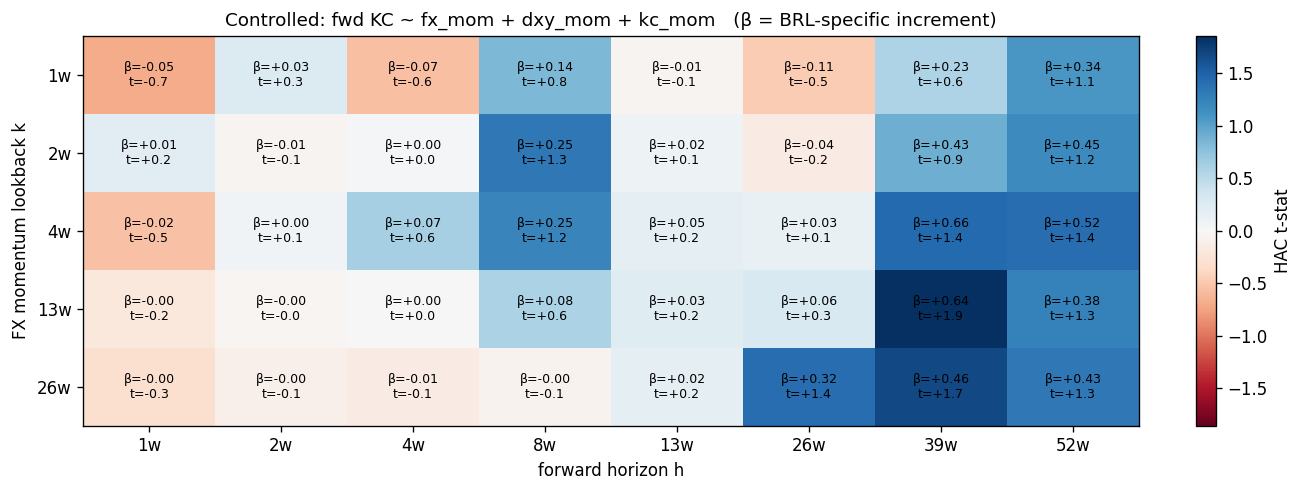

No raw-significant cells to re-examine.

Controlled survivors (β<0, p<0.05): n=0
Adjacent-pair condition (Gate G2): FAIL

Reverse check — significant cells (p<0.05), no controls:
  KC momentum → future USDBRL : 1 of 40
  (forward direction, with controls: 0)
Interpretation: strong asymmetry favors FX→KC; symmetry suggests a residual common factor.


In [7]:
# ── Controlled grid ─────────────────────────────────────────────────────────
grid_ctrl = grid_regressions(wk_core, "fx_mom", controls=True)
plot_grid(grid_ctrl, "Controlled: fwd KC ~ fx_mom + dxy_mom + kc_mom   "
                     "(β = BRL-specific increment)")
plt.tight_layout()
plt.show()

# ── Before/after comparison for every raw-significant cell ─────────────────
merged = grid_raw.merge(grid_ctrl, on=["k", "h"], suffixes=("_raw", "_ctrl"))
was_sig = merged.query("p_raw < 0.05")
if len(was_sig):
    print("Effect of controls on raw-significant cells:")
    print(f"{'cell':>10s} {'t raw':>7s} {'t ctrl':>7s} {'p ctrl':>8s}  verdict")
    print("─" * 48)
    for _, r in was_sig.iterrows():
        verdict = ("survives" if (r.p_ctrl < G2_P_MAX and r.beta_ctrl < 0)
                   else "killed by controls")
        print(f"  k={int(r.k):>2d} h={int(r.h):>2d} {r.t_raw:>7.2f} "
              f"{r.t_ctrl:>7.2f} {r.p_ctrl:>8.4f}  {verdict}")
else:
    print("No raw-significant cells to re-examine.")

# ── Survivors + adjacency (Gate G2 input) ──────────────────────────────────
surv = grid_ctrl.query(f"p < {G2_P_MAX} and beta < 0")[["k", "h"]]
surv_set = {(int(k), int(h)) for k, h in surv.values}   # plain ints for clean printing

def has_adjacent_pair(cells, ks=K_WEEKS, hs=H_WEEKS):
    """True if any two surviving cells are one grid-step apart in k or h."""
    pos = {(ks.index(k), hs.index(h)) for k, h in cells}
    return any(
        ((i + di, j + dj) in pos)
        for (i, j) in pos
        for di, dj in [(0, 1), (1, 0)]
    )

G2_PASS = has_adjacent_pair(surv_set)
surv_disp = sorted(surv_set)
print(f"\nControlled survivors (β<0, p<{G2_P_MAX}): n={len(surv_disp)}")
if surv_disp:
    shown = ", ".join(f"({k},{h})" for k, h in surv_disp[:12])
    print(f"  cells (k,h): {shown}{' …' if len(surv_disp) > 12 else ''}")
print(f"Adjacent-pair condition (Gate G2): {'PASS' if G2_PASS else 'FAIL'}")

# ── Reverse direction: does KC momentum predict USD/BRL? ───────────────────
wk_rev = wk.copy()
lp_brl = np.log(wk_rev["BRL"])
for h in H_WEEKS:
    wk_rev[f"fwdfx_{h}w"] = lp_brl.shift(-h) - lp_brl
grid_rev = grid_regressions(wk_rev.loc[CORE_START:CORE_END], "kc_mom",
                            controls=False, target_prefix="fwdfx")
n_rev = len(grid_rev.query("p < 0.05"))
n_fwd = len(grid_ctrl.query("p < 0.05"))
print("\nReverse check — significant cells (p<0.05), no controls:")
print(f"  KC momentum → future USDBRL : {n_rev} of {len(grid_rev.dropna(subset=['p']))}")
print(f"  (forward direction, with controls: {n_fwd})")
print("Interpretation: strong asymmetry favors FX→KC; symmetry suggests a "
      "residual common factor.")

### 4d. Granger Causality — Both Directions, Version-Proof

A complementary lens: instead of long-horizon forward returns, ask whether *p* lags of weekly FX returns jointly improve one-week-ahead KC forecasts beyond KC's own *p* lags (and vice versa). This is the classic Granger F-test, implemented manually as restricted-vs-unrestricted OLS — ~15 transparent lines instead of a library call whose signature keeps changing, and every intermediate quantity is inspectable.

```
unrestricted:  kc_ret[t] = α + Σᵢ φᵢ·kc_ret[t−i] + Σᵢ ψᵢ·fx_ret[t−i] + ε
restricted :   kc_ret[t] = α + Σᵢ φᵢ·kc_ret[t−i]                      + ε
F = [(SSR_r − SSR_u)/p] / [SSR_u/(n − 2p − 1)]
```

Note the scope difference from §4b: Granger tests *one-week-ahead* incremental content of the lag structure; the grid tests *multi-week cumulative* returns. A signal can pass one and fail the other — slow-burn effects show up in the grid, fast ones here.

In [8]:
def granger_f(y, x, p):
    """Manual Granger F-test: do p lags of x improve the AR(p) of y?
    y, x : aligned weekly return Series.  Returns (F, p-value, n)."""
    df_ = pd.DataFrame({"y": y, "x": x})
    for i in range(1, p + 1):
        df_[f"y_l{i}"] = df_["y"].shift(i)
        df_[f"x_l{i}"] = df_["x"].shift(i)
    df_ = df_.dropna()
    n = len(df_)
    ycols = [f"y_l{i}" for i in range(1, p + 1)]
    xcols = [f"x_l{i}" for i in range(1, p + 1)]
    ssr_u = sm.OLS(df_["y"], sm.add_constant(df_[ycols + xcols])).fit().ssr
    ssr_r = sm.OLS(df_["y"], sm.add_constant(df_[ycols])).fit().ssr
    dof = n - 2 * p - 1
    F = ((ssr_r - ssr_u) / p) / (ssr_u / dof)
    return F, 1 - stats.f.cdf(F, p, dof), n

ret_core = np.log(wk_core[["KC", "BRL"]]).diff().dropna()
print("Granger causality on weekly returns (core window):")
print(f"{'lags p':>7s} {'FX→KC  F':>10s} {'p-val':>8s}   {'KC→FX  F':>10s} {'p-val':>8s}")
print("─" * 52)
granger_fx_to_kc = {}
for p_lag in [1, 4, 13]:
    f1, p1, _ = granger_f(ret_core["KC"],  ret_core["BRL"], p_lag)
    f2, p2, _ = granger_f(ret_core["BRL"], ret_core["KC"],  p_lag)
    granger_fx_to_kc[p_lag] = p1
    s1 = "*" if p1 < 0.05 else " "
    s2 = "*" if p2 < 0.05 else " "
    print(f"{p_lag:>7d} {f1:>10.3f} {p1:>8.4f}{s1}  {f2:>10.3f} {p2:>8.4f}{s2}")
print("\n('*' = p<0.05. One-week-ahead lens — complements, not replaces, §4b/§4c.)")

Granger causality on weekly returns (core window):
 lags p   FX→KC  F    p-val     KC→FX  F    p-val
────────────────────────────────────────────────────
      1      0.202   0.6531        3.718   0.0542 
      4      0.898   0.4646        1.495   0.2018 
     13      1.030   0.4196        1.337   0.1857 

('*' = p<0.05. One-week-ahead lens — complements, not replaces, §4b/§4c.)


## 5. Out-of-Sample Validation

In-sample survivors can still be artifacts of the very scan that found them. The antidote is a walk-forward test on the **single best controlled cell** (max |t| among §4c survivors; if none survived, the pre-registered default `(k=13, h=13)` is used and this section is explicitly *exploratory*).

**Protocol — no information leaks:**
- At each week *t* (from 2015 on), re-fit the controlled regression using only rows whose forward return is *fully realized* by *t* — training rows stop at `t − h` weeks. This is stricter than "data before t": a row dated t−1 contains a forward return that reaches h−1 weeks *past* t and would leak.
- Predict `fwd_h[t]`, store, roll forward. Expanding window (uses all clean history each week).

**Metrics:**
- `OOS R² (vs zero)` = 1 − SSE(model)/SSE(zero-forecast) — did the model beat "returns are unpredictable"?
- `OOS R² (vs mean)` = Campbell–Thompson style, against the expanding historical mean — the harder, standard benchmark in return-prediction work. Values above ~1–2% at monthly-scale horizons are already economically meaningful in that literature.
- **Directional hit rate** on *non-overlapping* predictions (every h-th week — overlapping forwards would pseudo-replicate hits), with an exact binomial p-value.
- The **cumulative SSE-gain curve** shows *when* the edge lived — a signal that made all its money in 2015–16 and flatlined since is a historical fact, not a live tool.

⚠ No controlled survivors — using pre-registered default k*=13w, h*=13w. Section is EXPLORATORY; G2 already failed.
n predictions        : 589  (2015-01-02 → 2026-04-10)
OOS R² vs zero       : -0.0217
OOS R² vs exp. mean  : -0.0235
Hit rate (non-overl.): 19/46 = 41.3%  (binomial p = 0.302)


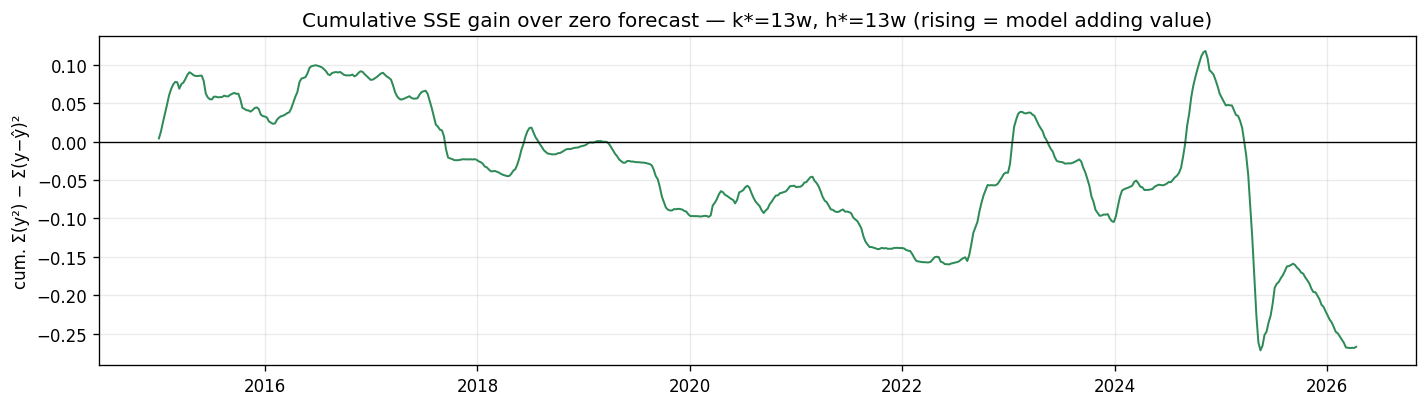

In [9]:
# ── Cell selection ──────────────────────────────────────────────────────────
if len(surv_set):
    best = (grid_ctrl.query(f"p < {G2_P_MAX} and beta < 0")
            .assign(abst=lambda d: d.t.abs())
            .sort_values("abst", ascending=False)
            .iloc[0])
    K_STAR, H_STAR = int(best.k), int(best.h)
    exploratory = False
    print(f"Selected cell (max |t| among controlled survivors): "
          f"k*={K_STAR}w, h*={H_STAR}w  (t={best.t:+.2f}, p={best.p:.4f})")
else:
    K_STAR, H_STAR = 13, 13
    exploratory = True
    print("⚠ No controlled survivors — using pre-registered default "
          f"k*={K_STAR}w, h*={H_STAR}w. Section is EXPLORATORY; "
          "G2 already failed.")

# ── Walk-forward engine (reused for the §7 index) ──────────────────────────
def walk_forward(df, sig_prefix, k, h, start=OOS_START, min_train=260,
                 ctrl_prefixes=("dxy_mom", "kc_mom")):
    """Expanding-window OOS predictions of fwd_{h}w from {sig,ctrl}_{k}w.

    Training rows for a prediction at positional index i are rows [0 : i−h]
    — only rows whose forward return is fully realized by time i.
    Returns DataFrame(date, y, yhat) over the prediction span.
    """
    cols = [f"{sig_prefix}_{k}w"] + [f"{c}_{k}w" for c in ctrl_prefixes]
    ycol = f"fwd_{h}w"
    sub = df[cols + [ycol]].copy()
    feat_ok = sub[cols].notna().all(axis=1)
    X_all = sub[cols].to_numpy(float)
    y_all = sub[ycol].to_numpy(float)
    dates = sub.index
    start_ts = pd.Timestamp(start)

    out = []
    for i in range(len(sub)):
        if dates[i] < start_ts or not feat_ok.iloc[i] or np.isnan(y_all[i]):
            continue
        tr = slice(0, max(0, i - h))
        Xtr, ytr = X_all[tr], y_all[tr]
        m = ~(np.isnan(Xtr).any(axis=1) | np.isnan(ytr))
        if m.sum() < min_train:
            continue
        A = np.column_stack([np.ones(m.sum()), Xtr[m]])
        coef, *_ = np.linalg.lstsq(A, ytr[m], rcond=None)
        yhat = coef[0] + X_all[i] @ coef[1:]
        out.append((dates[i], y_all[i], yhat))
    return pd.DataFrame(out, columns=["date", "y", "yhat"]).set_index("date")


def oos_report(oos, h, label=""):
    """Compute + print OOS metrics; returns dict for downstream use."""
    y, yhat = oos["y"].to_numpy(), oos["yhat"].to_numpy()
    sse_model = ((y - yhat) ** 2).sum()
    r2_zero = 1 - sse_model / (y ** 2).sum()
    hist_mean = pd.Series(y).expanding().mean().shift(1).fillna(0).to_numpy()
    r2_mean = 1 - sse_model / ((y - hist_mean) ** 2).sum()
    nol = oos.iloc[::h]                                  # non-overlapping subset
    hits = (np.sign(nol["y"]) == np.sign(nol["yhat"])).sum()
    n_nol = len(nol)
    p_binom = stats.binomtest(int(hits), n_nol, 0.5).pvalue if n_nol else np.nan
    print(f"{label}n predictions        : {len(oos)}  "
          f"({oos.index[0].date()} → {oos.index[-1].date()})")
    print(f"{label}OOS R² vs zero       : {r2_zero:+.4f}")
    print(f"{label}OOS R² vs exp. mean  : {r2_mean:+.4f}")
    print(f"{label}Hit rate (non-overl.): {hits}/{n_nol} = "
          f"{hits/n_nol:.1%}  (binomial p = {p_binom:.3f})")
    return dict(r2_zero=r2_zero, r2_mean=r2_mean,
                hit=hits / n_nol if n_nol else np.nan, p_binom=p_binom)

oos_brl = walk_forward(wk, "fx_mom", K_STAR, H_STAR)
stats_oos = oos_report(oos_brl, H_STAR)

# ── Cumulative SSE gain vs zero forecast — when did the edge live? ─────────
gain = (oos_brl["y"] ** 2 - (oos_brl["y"] - oos_brl["yhat"]) ** 2).cumsum()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(gain.index, gain, lw=1.2, color="seagreen")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Cumulative SSE gain over zero forecast — k*={K_STAR}w, h*={H_STAR}w "
             "(rising = model adding value)")
ax.set_ylabel("cum. Σ(y²) − Σ(y−ŷ)²")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. The FX Timing Rule — Economic Translation

Statistics answered "is there a lead?"; a roaster's question is "**does acting on it lower my procurement cost?**" Two metrics are computed: notebook 01's signal-weighted-average yardstick (kept for direct cross-notebook comparison) and a deferral-accounting metric that Gate G3 is judged on — the reasoning for the switch is below, written *before* looking at real data.

**Setup.** The decision cadence *adapts to the signal's horizon*. A short-horizon cell cannot survive monthly sampling — converting `h*=2w` to `h=1m` discards ¾ of the decision points and scores the model on a ~4.3-week return its 2-week kernel never claimed to predict (synthetic validation confirmed this destroys a genuinely planted signal). So: cells with `h* < 4` weeks run at **weekly** cadence; longer cells map to **monthly** procurement rhythm (`÷ 4.345`, rounded, min 1). Weekly purchase-timing shifts are operationally realistic for a roaster buying on the spot/differential market. At each decision date *t*:

1. Re-fit the controlled prediction on an expanding window with the same `t − h` no-leak rule as §5 → predicted h-month KC return `ŷ[t]`.
2. Standardize: `z[t] = ŷ[t] / σ[t]` where σ is the *training-window* std of realized h-month returns (no look-ahead in the scaling either).
3. Purchase weight: `w[t] = clip(1 + z[t], 0.25, 1.75)`.

**Weight logic.** A buyer with steady demand lowers average cost by shifting volume toward months that *precede price rises* (buy before it's expensive) and away from months that *precede declines* (wait for it to get cheap). So `w > 1` when the model expects KC to rise, `w < 1` when it expects a fall. Clipping keeps the rule implementable — a real roastery cannot buy 0× or 5× a normal month (storage, cash, freshness). Weights use only information ≤ *t*; prices paid are actual month-end settles.

**Two metrics — and why the gate uses the second one.**

1. *Signal-weighted average price* (notebook 01's metric): `(naive avg − Σw·P/Σw) / naive avg`. This rewards holding **low weights in high-price-level months**, i.e. it measures covariance between the weight and the price *level*. That was the right yardstick for 01, whose signal *is* a price-level position. But the FX kernel forecasts **returns** — it says "KC will rise/fall over the next h months," and is deliberately blind to whether the level is 120 or 320. Scoring a level-blind forecast on a level-covariance metric produces near-noise: the rule can time every move correctly and still show ≈0 (or negative) if high-level months happened to draw slightly high weights. Reported for cross-notebook comparability only.

2. *Deferral accounting* (**Gate G3**): at each decision date the rule shifts `δ_t = w_t − 1` of a baseline unit between period *t* and period *t+h* — front-load before an expected rise (δ>0: buy at `P_t` instead of `P_{t+h}`), defer before an expected fall (δ<0). Per-period saving is `δ_t · (P_{t+h} − P_t)`; total saving as % of baseline budget is `Σ δ_t (P_{t+h} − P_t) / Σ P_t × 100`, over decision dates whose forward leg is realized (the last h are dropped — no phantom trades). This is the cash a return forecast actually earns, matched to what the model claims to know.

**Carrying-cost caveat.** Front-loading incurs storage + financing, roughly 0.5–1%/yr on green coffee — small at h ≤ 3 months (≲0.25% of shifted volume, which is itself a fraction of budget) but not zero; a production version would net it out explicitly.

**Gate G3: deferral saving ≥ 1.0% of baseline budget** over 2015+, with the per-year breakdown — a rule that earned everything in one regime and nothing since is a fact worth knowing. (01 cleared 3% at 18–24m on its level metric; FX operates at shorter horizons where less is achievable — 1% on a seven-figure green-coffee budget is still real money.)

Validated cell (k*=13w, h*=13w) → monthly decisions (k=3, h=3 m-periods)

Evaluation window        : 2015-01-31 → 2026-04-30  (136 monthly decisions, 136 with realized forward leg)
Naive average price      :   176.27 USc/lb
FX-weighted average      :   180.13 USc/lb
Level-covariance saving  : -2.19%   (01-comparable; level-blind forecast → expect ≈ noise)
Deferral saving (G3)     : -0.14%   (threshold ≥ 1.0%)


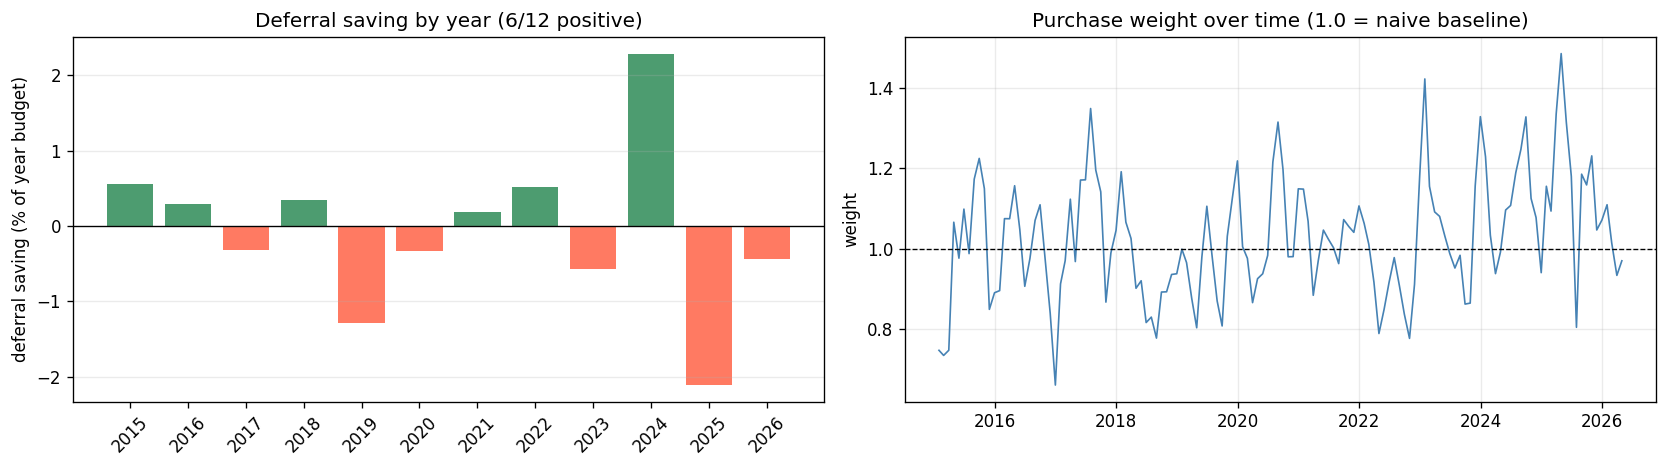

date
2015    0.56
2016    0.29
2017   -0.32
2018    0.35
2019   -1.29
2020   -0.32
2021    0.19
2022    0.52
2023   -0.57
2024    2.29
2025   -2.11
2026   -0.43


In [10]:
# ── Decision frame: cadence adapts to the validated cell's horizon ─────────
if H_STAR < 4:
    # short-horizon signal → weekly decisions; §3 frame reused verbatim
    CADENCE, K_M, H_M, MIN_TRAIN = "weekly", K_STAR, H_STAR, 260
    me = wk.copy()
else:
    # longer horizon → monthly procurement rhythm, same feature construction
    CADENCE, MIN_TRAIN = "monthly", 60
    K_M = max(1, round(K_STAR / 4.345))
    H_M = max(1, round(H_STAR / 4.345))
    me = prices[["KC", "BRL", "DXY"]].resample("ME").last().dropna(how="any")
    lpm = np.log(me)
    me[f"fx_mom_{K_M}w"]  = lpm["BRL"] - lpm["BRL"].shift(K_M)   # '_w' suffix kept
    me[f"dxy_mom_{K_M}w"] = lpm["DXY"] - lpm["DXY"].shift(K_M)   # so walk_forward()
    me[f"kc_mom_{K_M}w"]  = lpm["KC"]  - lpm["KC"].shift(K_M)    # is reused verbatim
    me[f"fwd_{H_M}w"]     = lpm["KC"].shift(-H_M) - lpm["KC"]    # ("w" = generic)
print(f"Validated cell (k*={K_STAR}w, h*={H_STAR}w) → {CADENCE} decisions "
      f"(k={K_M}, h={H_M} {CADENCE[0]}-periods)")

def timing_rule(me_df, sig_prefix, k, h, start=OOS_START, min_train=MIN_TRAIN,
                w_lo=0.25, w_hi=1.75):
    """Walk-forward purchase weights from OOS predictions.

    Inputs : decision frame with {sig,dxy_mom,kc_mom}_{k}w, fwd_{h}w, KC.
    Output : (result frame, metrics dict).
      result frame — yhat, sigma, z, w, delta, P_fwd, defer_saving (per period)
      metrics — naive / wavg / level_saving (01-comparable, level-covariance)
                and defer_saving (Gate G3: Σδ·(P₊ₕ−P)/ΣP ×100, realized rows)."""
    oos = walk_forward(me_df, sig_prefix, k, h, start=start, min_train=min_train)
    # training-window σ at each date: expanding std of *realized* fwd returns,
    # lagged h so the last h unrealized rows never enter the scale either
    fwd = me_df[f"fwd_{h}w"]
    sigma = fwd.expanding(min_periods=24).std().shift(h)
    res = oos.join(me_df["KC"], how="left").join(sigma.rename("sigma"), how="left")
    res = res.dropna(subset=["sigma", "KC"])
    res["z"] = res["yhat"] / res["sigma"]
    res["w"] = (1 + res["z"]).clip(w_lo, w_hi)

    # metric 1 — level-covariance (01-comparable, NOT the gate; see markdown)
    naive    = res["KC"].mean()
    weighted = (res["KC"] * res["w"]).sum() / res["w"].sum()
    level    = (naive - weighted) / naive * 100

    # metric 2 — deferral accounting (Gate G3)
    res["delta"] = res["w"] - 1.0                          # volume shifted t → t+h
    res["P_fwd"] = me_df["KC"].shift(-h).reindex(res.index)  # realized price at t+h
    real = res.dropna(subset=["P_fwd"])                    # drop last h phantom rows
    res["defer_saving"] = res["delta"] * (res["P_fwd"] - res["KC"])  # per-month $
    defer = (real["delta"] * (real["P_fwd"] - real["KC"])).sum() \
            / real["KC"].sum() * 100

    metrics = {"naive": naive, "wavg": weighted,
               "level_saving": level, "defer_saving": defer,
               "n_realized": len(real)}
    return res, metrics

rule_brl, m_brl = timing_rule(me, "fx_mom", K_M, H_M)
SAVING_BRL       = m_brl["defer_saving"]    # Gate G3 input
LEVEL_SAVING_BRL = m_brl["level_saving"]    # 01-comparable secondary
print(f"\nEvaluation window        : {rule_brl.index[0].date()} → "
      f"{rule_brl.index[-1].date()}  ({len(rule_brl)} {CADENCE} decisions, "
      f"{m_brl['n_realized']} with realized forward leg)")
print(f"Naive average price      : {m_brl['naive']:8.2f} USc/lb")
print(f"FX-weighted average      : {m_brl['wavg']:8.2f} USc/lb")
print(f"Level-covariance saving  : {LEVEL_SAVING_BRL:+.2f}%   "
      f"(01-comparable; level-blind forecast → expect ≈ noise)")
print(f"Deferral saving (G3)     : {SAVING_BRL:+.2f}%   "
      f"(threshold ≥ {G3_SAVING_MIN:.1f}%)")

# ── Annual breakdown (deferral metric — what the gate is judged on) ────────
by_year = rule_brl.dropna(subset=["P_fwd"]).groupby(
    rule_brl.dropna(subset=["P_fwd"]).index.year).apply(
    lambda g: (g["delta"] * (g["P_fwd"] - g["KC"])).sum() / g["KC"].sum() * 100
)
pos_years = int((by_year > 0).sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["seagreen" if v > 0 else "tomato" for v in by_year]
axes[0].bar(by_year.index.astype(str), by_year.values, color=colors, alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Deferral saving by year ({pos_years}/{len(by_year)} positive)")
axes[0].set_ylabel("deferral saving (% of year budget)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(rule_brl.index, rule_brl["w"], lw=1.0, color="steelblue")
axes[1].axhline(1.0, color="black", lw=0.8, ls="--")
axes[1].set_title("Purchase weight over time (1.0 = naive baseline)")
axes[1].set_ylabel("weight")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(by_year.round(2).rename("saving_%").to_string())

## 7. Generalization — Import-Weighted Producer-FX Index

The BRL hypothesis generalizes: if producer-currency weakness encourages selling, then a basket of origin currencies **weighted by where US green coffee actually comes from** should carry the aggregate version of the signal. This section builds that index and re-runs the §4c/§6 machinery unchanged — a clean head-to-head: *does broadening add information, or dilute BRL?*

**Import weights.** Approximate recent shares of US unroasted-coffee imports by value (HS 0901.11) — **hardcoded and clearly labeled as figures to refresh**, sourced from US Census trade data / USDA FAS GATS as of early 2026. They are deliberately a config dict, not a hidden constant: refresh via USA Trade Online (Census) or FAS GATS for HS 0901.11, most recent 12 months. Two structural notes that no weighting scheme fixes:

- **Only float-classified currencies (§2) enter.** A pegged rate contributes zeros; renormalizing over the float set concentrates weight in the Latin American floats. Expect the index to be ~half BRL *by construction* — printed below so the "diversification" on offer is visible, not assumed.
- Vietnam is ~90% robusta — its weight is relevant to *blended* retail coffee costs but only weakly to KC (an Arabica contract). VND is managed anyway, so the float filter mostly moots this; it would matter for a robusta (RC) extension.

Index return: `Σᵢ wᵢ · Δlog(USDLOCᵢ)` over the float set, weights renormalized — rising index = origin currencies weakening on average, same sign convention as BRL throughout.

Index composition (float-classified ∩ available, renormalized):
  BRL: raw 0.280 → index 0.361
  COP: raw 0.200 → index 0.258
  HNL: raw 0.060 → index 0.077
  GTQ: raw 0.055 → index 0.071
  PEN: raw 0.045 → index 0.058
  MXN: raw 0.045 → index 0.058
  NIO: raw 0.035 → index 0.045
  ETB: raw 0.030 → index 0.039
  IDR: raw 0.025 → index 0.032
  → BRL is 36% of the index (concentration is structural, not a bug)


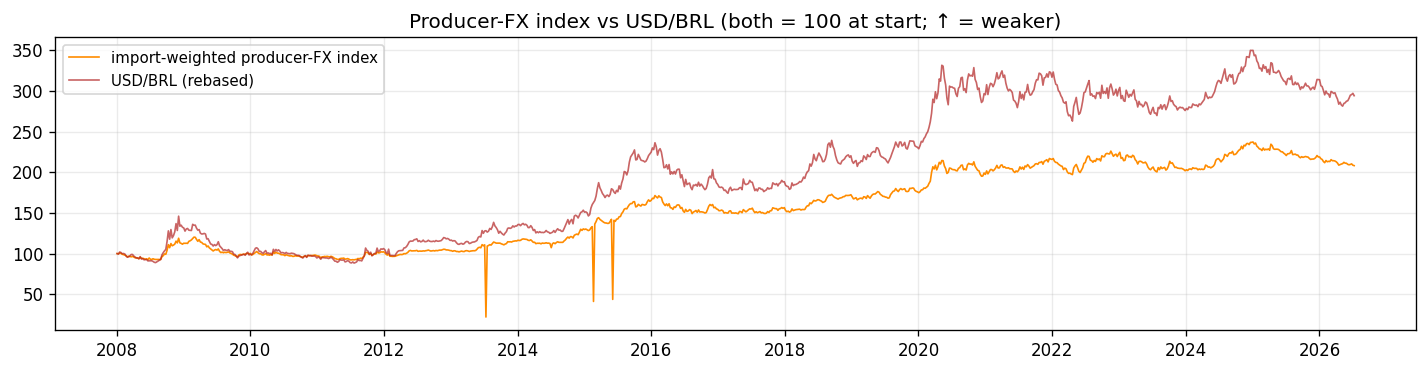

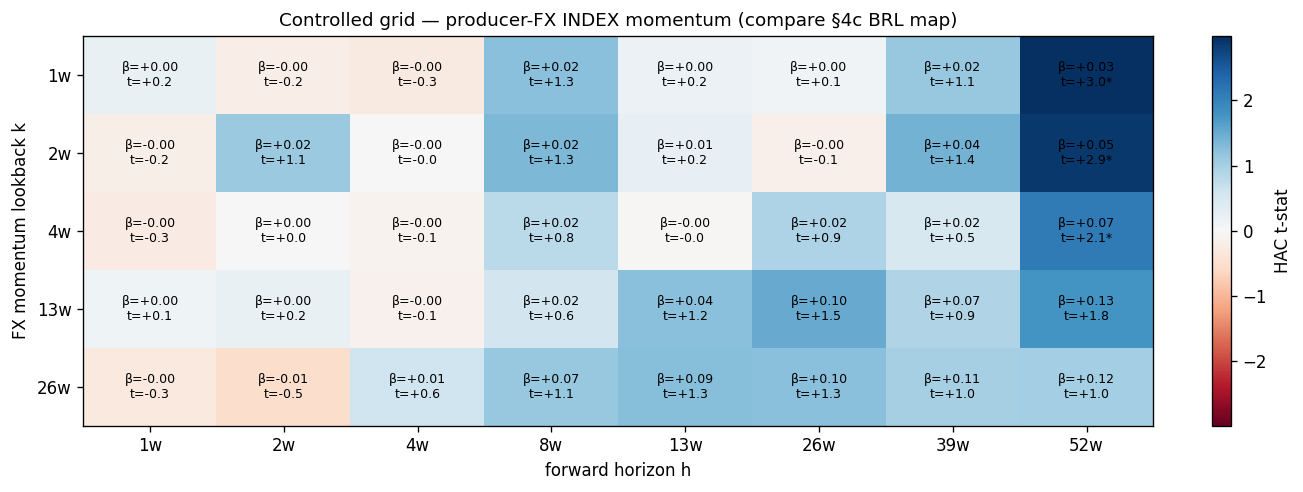

Index OOS (same k*, h* cell):
  n predictions        : 589  (2015-01-02 → 2026-04-10)
  OOS R² vs zero       : -0.0163
  OOS R² vs exp. mean  : -0.0181
  Hit rate (non-overl.): 19/46 = 41.3%  (binomial p = 0.302)

Head-to-head:
                                BRL only  FX index
max |t| (controlled grid)          1.855     2.985
OOS R² vs zero                    -0.022    -0.016
hit rate                           0.413     0.413
deferral saving % (G3 metric)     -0.143    -0.133
level saving % (01-comparable)    -2.190    -1.937

Reading: if the index column isn't clearly better, BRL alone carries the signal and the basket mostly adds noise-weighted zeros.


In [11]:
# ── Import weights — APPROXIMATE, REFRESH BEFORE PRODUCTION USE ────────────
# Source: US Census / USDA FAS, unroasted coffee (HS 0901.11) import value
# shares, recent-year approximations as of early 2026. Remainder (~15–20%:
# Costa Rica, Papua New Guinea, EU/Swiss re-exports, ...) intentionally
# excluded — no liquid or informative currency to map it to.
IMPORT_WEIGHTS = {
    "BRL": 0.28, "COP": 0.20, "VND": 0.09, "HNL": 0.060, "GTQ": 0.055,
    "PEN": 0.045, "MXN": 0.045, "NIO": 0.035, "ETB": 0.030, "IDR": 0.025,
}

usable = {c: w for c, w in IMPORT_WEIGHTS.items()
          if float_status.get(c, False) and c in prices.columns}
tot = sum(usable.values())
idx_w = {c: w / tot for c, w in usable.items()}

print("Index composition (float-classified ∩ available, renormalized):")
for c, w in sorted(idx_w.items(), key=lambda kv: -kv[1]):
    print(f"  {c}: raw {IMPORT_WEIGHTS[c]:.3f} → index {w:.3f}")
print(f"  → BRL is {idx_w.get('BRL', 0):.0%} of the index (concentration is "
      "structural, not a bug)")

# ── Weekly index + §3-identical features under prefix 'idx_mom' ────────────
fx_wk = prices[list(idx_w)].resample("W-FRI").last()
idx_ret = sum(w * (np.log(fx_wk[c]).diff()) for c, w in idx_w.items())
wk["IDX"] = idx_ret.reindex(wk.index).fillna(0).cumsum()       # log-level, base 0
for k in K_WEEKS:
    wk[f"idx_mom_{k}w"] = wk["IDX"] - wk["IDX"].shift(k)
wk_core = wk.loc[CORE_START:CORE_END]                          # refresh view

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(wk.index, np.exp(wk["IDX"]) * 100, lw=1.0, color="darkorange",
        label="import-weighted producer-FX index")
ax.plot(wk.index, wk["BRL"] / wk["BRL"].iloc[0] * 100, lw=1.0,
        color="firebrick", alpha=0.7, label="USD/BRL (rebased)")
ax.set_title("Producer-FX index vs USD/BRL (both = 100 at start; ↑ = weaker)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ── Head-to-head: controlled grid + timing rule, identical machinery ───────
grid_idx = grid_regressions(wk_core, "idx_mom", controls=True)
plot_grid(grid_idx, "Controlled grid — producer-FX INDEX momentum "
                    "(compare §4c BRL map)")
plt.tight_layout()
plt.show()

if CADENCE == "weekly":
    me = wk.copy()                       # refresh — wk now carries idx_mom_{k}w
else:
    me["IDX"] = idx_ret.resample("ME").sum().reindex(me.index).fillna(0).cumsum()
    me[f"idx_mom_{K_M}w"] = me["IDX"] - me["IDX"].shift(K_M)
rule_idx, m_idx = timing_rule(me, "idx_mom", K_M, H_M)
SAVING_IDX = m_idx["defer_saving"]
oos_idx = walk_forward(wk, "idx_mom", K_STAR, H_STAR)
print("Index OOS (same k*, h* cell):")
stats_idx = oos_report(oos_idx, H_STAR, label="  ")

best_brl_t = grid_ctrl.assign(a=lambda d: d.t.abs()).a.max()
best_idx_t = grid_idx.assign(a=lambda d: d.t.abs()).a.max()
comp = pd.DataFrame({
    "BRL only":  [best_brl_t, stats_oos["r2_zero"], stats_oos["hit"],
                  SAVING_BRL, LEVEL_SAVING_BRL],
    "FX index":  [best_idx_t, stats_idx["r2_zero"], stats_idx["hit"],
                  SAVING_IDX, m_idx["level_saving"]],
}, index=["max |t| (controlled grid)", "OOS R² vs zero", "hit rate",
          "deferral saving % (G3 metric)", "level saving % (01-comparable)"])
print("\nHead-to-head:")
print(comp.round(3).to_string())
print("\nReading: if the index column isn't clearly better, BRL alone carries "
      "the signal and the basket mostly adds noise-weighted zeros.")

## 8. Findings — Gate Evaluation & Limitations

The cell below evaluates the three gates programmatically from quantities computed upstream — no re-derivation, no opportunity for the narrative to drift from the numbers. Interpretation guide:

- **All three pass** → the producer-FX signal graduates to a candidate input for the composite (alongside 01's price-position signal). Next step would be interaction analysis: does FX add value *conditional* on price position, or do they fire at the same times?
- **G1 passes, G2/G3 fail** → the co-movement is real but not exploitably *predictive* at these horizons — consistent with FX and KC being near-simultaneous responses to common news. The honest conclusion would be "BRL is a *conditioning/regime* variable, not a timing signal," and that is a useful PoC result.
- **G1 fails** → data or regime problem; nothing downstream is interpretable. Check §2 diagnostics and whether the sample is dominated by supply-shock years.

**Known limitations (flagged, not fixed, at PoC stage):**

1. **Front-month splice.** `KC=F` concatenates contracts; returns spanning roll dates include roll gaps (contango/backwardation jumps), adding noise — same limitation as notebook 01, so cross-notebook comparisons are consistent. A production version would build a back-adjusted series from individual contracts.
2. **Onshore/offshore BRL.** Yahoo's composite differs slightly from the Brazilian PTAX fix that governs actual producer economics; negligible at weekly horizons, worth revisiting for daily work.
3. **Multiple testing residue.** The cluster + controls + OOS discipline reduces but cannot eliminate selection effects — the *magnitude* of the best cell's edge is biased upward even when the *existence* of the effect is genuine (winner's curse). Treat point estimates as ceilings.
4. **Regime dependence** (§4a): supply-shock years invert the contemporaneous relation. A production rule should probably gate on a supply-stress indicator (e.g., 01's realized-variance regime flag).
5. **Import weights are approximations** to be refreshed from Census/FAS; the float filter concentrates the index in Latin American currencies regardless of the exact numbers.
6. **Sample = one macro era.** 2010–2024 contains two BRL crises and one commodity supercycle; 15 years of monthly-scale horizons is ~7–8 independent observations of a 24-month cycle.

In [12]:
G1_PASS = R_MONTHLY_CONTEMP <= G1_R_MAX
G3_PASS = SAVING_BRL >= G3_SAVING_MIN

print("═" * 62)
print("GATE EVALUATION")
print("═" * 62)
print(f"G1  monthly contemporaneous r ≤ {G1_R_MAX:+.2f}")
print(f"    measured: {R_MONTHLY_CONTEMP:+.3f}                → "
      f"{'PASS ✓' if G1_PASS else 'FAIL ✗'}")
print(f"G2  adjacent controlled survivors (β<0, p<{G2_P_MAX})")
print(f"    survivors: n={len(surv_set)}"
      + (f", e.g. {sorted(surv_set)[:6]}" if surv_set else " (none)")
      + f"  → {'PASS ✓' if G2_PASS else 'FAIL ✗'}")
print(f"G3  walk-forward deferral saving ≥ {G3_SAVING_MIN:.1f}% of budget")
print(f"    measured: {SAVING_BRL:+.2f}%  (level-metric, 01-comparable: "
      f"{LEVEL_SAVING_BRL:+.2f}%)  → {'PASS ✓' if G3_PASS else 'FAIL ✗'}")
print("═" * 62)
n_pass = sum([G1_PASS, G2_PASS, G3_PASS])
verdict = {
    3: "Signal validated at PoC level → candidate for composite integration.",
    2: "Partial validation → see §8 interpretation guide for which claim survives.",
    1: "Weak support → likely conditioning variable, not a timing signal.",
    0: "Hypothesis not supported in this sample → documented negative result.",
}[n_pass]
print(f"\n{n_pass}/3 gates passed. {verdict}")
if exploratory:
    print("\n⚠ Reminder: §5/§6 ran on the pre-registered default cell because no "
          "cell survived controls — treat G3 as exploratory regardless of value.")

══════════════════════════════════════════════════════════════
GATE EVALUATION
══════════════════════════════════════════════════════════════
G1  monthly contemporaneous r ≤ -0.20
    measured: -0.316                → PASS ✓
G2  adjacent controlled survivors (β<0, p<0.05)
    survivors: n=0 (none)  → FAIL ✗
G3  walk-forward deferral saving ≥ 1.0% of budget
    measured: -0.14%  (level-metric, 01-comparable: -2.19%)  → FAIL ✗
══════════════════════════════════════════════════════════════

1/3 gates passed. Weak support → likely conditioning variable, not a timing signal.

⚠ Reminder: §5/§6 ran on the pre-registered default cell because no cell survived controls — treat G3 as exploratory regardless of value.


## 9. Reference Output

Weekly reference series for downstream composite work: prices, the validated momentum feature for both BRL and the index, and the walk-forward OOS predictions (the only model outputs that are honestly usable downstream — in-sample fitted values would smuggle look-ahead into anything built on top).

In [ ]:
ref = wk[["KC", "BRL", "DXY",
          f"fx_mom_{K_STAR}w", f"idx_mom_{K_STAR}w"]].copy()
ref = ref.join(oos_brl["yhat"].rename("oos_pred_brl"), how="left")
ref = ref.join(oos_idx["yhat"].rename("oos_pred_idx"), how="left")

out_path = DATA_DIR / "02_fx_signal_reference.csv"
ref.to_csv(out_path, float_format="%.6f")
print(f"Wrote {out_path}  ({len(ref)} weekly rows × {len(ref.columns)} cols)")
print(f"Columns: {list(ref.columns)}")
print(f"OOS prediction coverage: {ref['oos_pred_brl'].notna().sum()} weeks")